In [1]:
pip install statsmodels

In [2]:
pip install japanize_matplotlib

     |████████████████████████████████| 4.1MB 12.7MB/s 
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-cp36-none-any.whl size=4120276 sha256=82cf7840e6e9211cc4c698b321699b92dbfb9ae0f56ea15dd1e92b8eae7abff2
  Stored in directory: /root/.cache/pip/wheels/b7/d9/a2/f907d50b32a2d2008ce5d691d30fb6569c2c93eefcfde55202
Successfully built japanize-matplotlib


In [3]:
%matplotlib inline
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import japanize_matplotlib

import statsmodels.api as sm
#from statsmodels.tsa.statespace.sarimax import SARIMAX
#import statsmodels.api as sm
#from statsmodels.graphics import arma_generate_sample

np.random.seed(0)

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [5]:
dfa = pd.read_csv('AP.txt', index_col='Date', parse_dates=True)
df = dfa.head(-12)

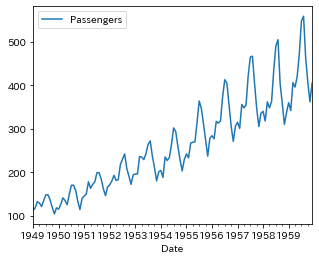

In [6]:
fig, ax = plt.subplots(figsize=(5,4))
fig2 = df.plot(ax=ax)
plt.show()

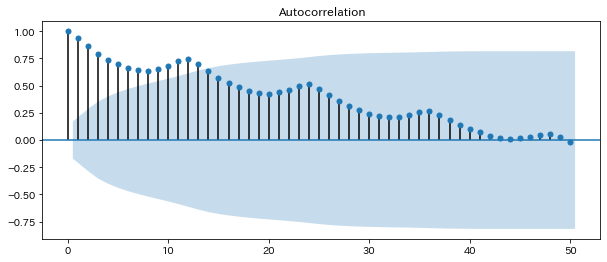

In [7]:
fig, ax = plt.subplots(figsize=(10,4))
fig2 = sm.graphics.tsa.plot_acf(df, lags=50,  alpha=0.05, ax=ax)
plt.show()

In [10]:
#result = sm.tsa.statespace.sarimax.SARIMAX(df, order=(3,1,2), seasonal_order=(1,1,1,12)).fit()
result = sm.tsa.SARIMAX(df, order=(3,1,2), seasonal_order=(1,1,1,12)).fit()

/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/base/tsa_model.py:165: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  % freq, ValueWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/base/model.py:512: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)


In [11]:
print(result.summary())

                                 Statespace Model Results                                 
Dep. Variable:                         Passengers   No. Observations:                  132
Model:             SARIMAX(3, 1, 2)x(1, 1, 1, 12)   Log Likelihood                -443.270
Date:                            Sun, 21 Feb 2021   AIC                            902.541
Time:                                    05:58:28   BIC                            924.774
Sample:                                01-01-1949   HQIC                           911.569
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5860      0.794      0.738      0.461      -0.971       2.143
ar.L2          0.3197      0.527   

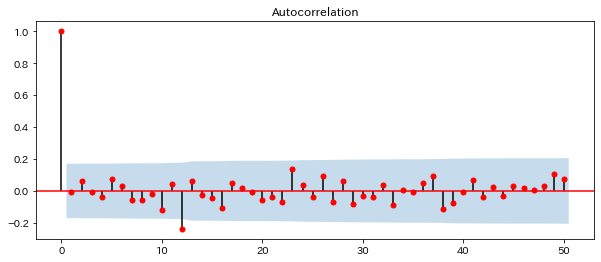

In [12]:
fig, ax = plt.subplots(figsize=(10,4))
fig2 = sm.graphics.tsa.plot_acf(result.resid, lags=50, ax=ax, color='r')
plt.show()

In [26]:
pred1 = result.predict(start='1960-01', end='1961-12')
pred2 = result.predict(end='1959-12')

No handles with labels found to put in legend.


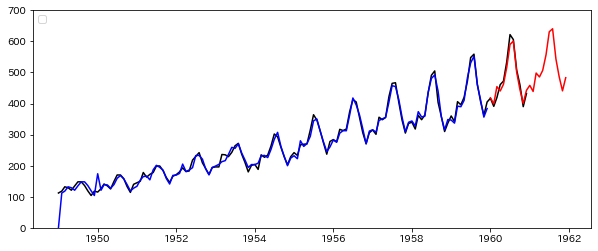

In [27]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(dfa, 'k')
#fig = sm.graphics.tsa.plot_predict(result, ax=ax)
#fig = sm.tsa.ARIMAResults.plot_predict(result,ax=ax)
plt.plot(pred1,'r')
plt.plot(pred2,'b')
ax.set_ylim([0,700])
legend = ax.legend(loc='upper left')
plt.show()

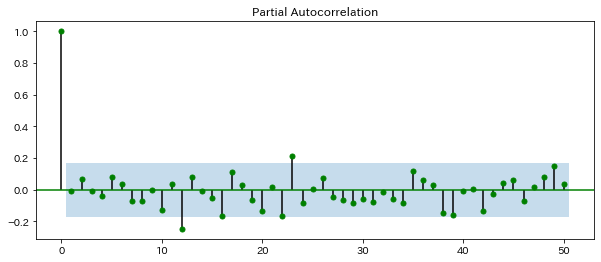

In [15]:
fig, ax = plt.subplots(figsize=(10,4))
fig2 = sm.graphics.tsa.plot_pacf(result.resid, lags=50, ax=ax, color='g')
plt.show()